# Customer Churn Prediction System

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "Tenure":[2,5,8,12,15,20,24,30,36,48],
    "MonthlyCharges":[70,65,80,55,50,45,40,35,30,25],
    "SupportCalls":[5,4,4,3,2,2,1,1,0,0],
    "Churn":[1,1,1,1,0,0,0,0,0,0]
}

df = pd.DataFrame(data)
df

,Tenure,MonthlyCharges,SupportCalls,Churn
0,2,70,5,1
1,5,65,4,1
2,8,80,4,1
3,12,55,3,1
4,15,50,2,0
5,20,45,2,0
6,24,40,1,0
7,30,35,1,0
8,36,30,0,0
9,48,25,0,0


In [11]:
print("===== Dataset Inspection  =====")
print(df.columns)
print(df.shape)
print(df.describe())
print(df.info())

===== Dataset Inspection  =====
Index(['Tenure', 'MonthlyCharges', 'SupportCalls', 'Churn'], dtype='str')
(10, 4)
         Tenure  MonthlyCharges  SupportCalls      Churn
count  10.00000       10.000000      10.00000  10.000000
mean   20.00000       49.500000       2.20000   0.400000
std    14.67424       18.020051       1.75119   0.516398
min     2.00000       25.000000       0.00000   0.000000
25%     9.00000       36.250000       1.00000   0.000000
50%    17.50000       47.500000       2.00000   0.000000
75%    28.50000       62.500000       3.75000   1.000000
max    48.00000       80.000000       5.00000   1.000000
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Tenure          10 non-null     int64
 1   MonthlyCharges  10 non-null     int64
 2   SupportCalls    10 non-null     int64
 3   Churn           10 non-null     int64
dtypes: int64(4)
memory u

In [13]:
x = df[["Tenure","MonthlyCharges","SupportCalls"]]
y = df["Churn"]

In [16]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    random_state = 42 , 
    test_size = 0.2
)

In [22]:
from sklearn.svm import SVC
model = SVC(kernel="linear",probability=True,random_state=42)
model.fit(x_train,y_train)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [23]:
model.score(x_train,y_train)*100

100.0

In [24]:
model.score(x_test,y_test)*100

100.0

In [61]:
new = [[15,50,12]]
prediction = model.predict(new)
if prediction[0] == 1:
    print("Customer will churn")
else:
    print("Customer will stay")

Customer will stay


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [55]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)*100

print("Accuracy :", accuracy)

Accuracy : 100.0


In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[1 0]
 [0 1]]


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [58]:
probability = model.predict_proba(new)*100
print(probability)

[[55.79640027 44.20359973]]


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


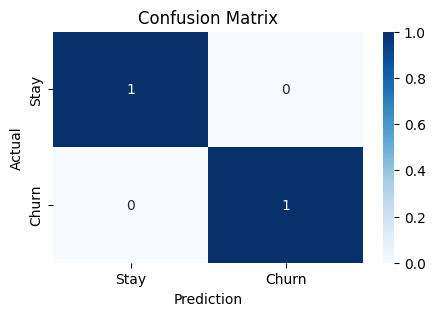

In [59]:
plt.figure(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay","Churn"],
    yticklabels=["Stay","Churn"]
)
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

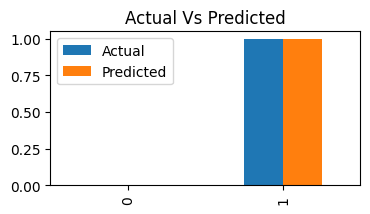

In [60]:
comparison = pd.DataFrame(
    {
        "Actual" : y_test.values,
        "Predicted" : y_pred
    }
)
comparison.plot(kind="bar",figsize=(4,2))
plt.title("Actual Vs Predicted")
plt.show()


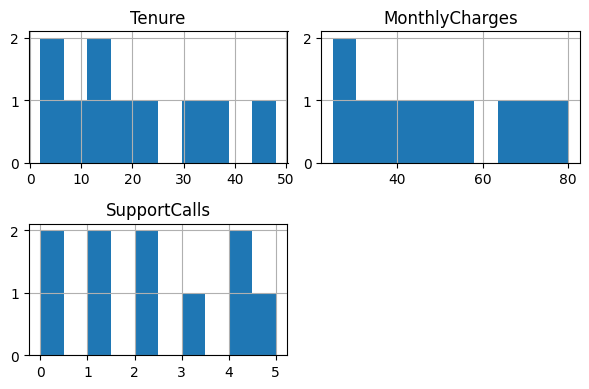

In [47]:
df[["Tenure","MonthlyCharges","SupportCalls"]].hist(figsize=(6,4))
plt.tight_layout()
plt.show()